In [ ]:


import os
import json
import copy
import random
import warnings
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import efficientnet_v2_l, EfficientNet_V2_L_Weights

from monai.losses import FocalLoss
from monai.utils import set_determinism

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
    classification_report, confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# ── Paths (iguais ao notebook anterior) ──────────────────────
DATA_ROOT    = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT  = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'efficientnet_v2_l_improved'
RESULTS_DIR  = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR   = os.path.join(MODELS_ROOT,  NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── Hiperparâmetros ──────────────────────────────────────────
SEED         = 42
IMG_SIZE     = 512
BATCH_SIZE   = 4      # igual ao anterior (50GB VRAM)
NUM_WORKERS  = 4
NUM_EPOCHS   = 40
PATIENCE     = 10
LR_HEAD      = 3e-4   # head nova — LR mais alto
LR_BACKBONE  = 5e-5   # backbone pré-treinado — LR mais baixo
WEIGHT_DECAY = 1e-4

# CLAHE ON — principal melhoria para fluoroscopia
USE_CLAHE      = True
CLAHE_CLIP     = 3.0   # clip limit ligeiramente mais alto que o padrão
GEOMETRY_MODE  = 'pad_resize_if_rect'

# Label smoothing — regulariza e reduz overfit em classes raras
LABEL_SMOOTHING = 0.1

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
    torch.cuda.empty_cache()
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:',  MODELS_DIR)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM (GB): 50.86216192
RESULTS_DIR: /mounts/mecd-ap-g5/results/efficientnet_v2_l_improved
MODELS_DIR: /mounts/mecd-ap-g5/models/efficientnet_v2_l_improved


In [108]:
# ============================================================
# CELL 2 — CARREGAR E FILTRAR METADADOS
# ============================================================

METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
df = pd.read_csv(METADATA_PATH)

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
FUSED_LABEL_MAP = {
    'Benign Stricture':    'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks':       'Biliary Leaks',
    'Lithiasis':           'Lithiasis',
    'Normal':              'Normal',
}
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df[
    (df['Keep'].astype(str).str.strip().str.lower() == 'keep') &
    (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))
].copy()
filtered['Label']       = filtered['Label'].astype(str).str.strip()
filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()
filtered['image_path']  = filtered['processed_image_path'].apply(
    lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', p)
)
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

class_names  = list(FINAL_CLASSES)
class_to_idx = {label_name: idx for idx, label_name in enumerate(class_names)}
filtered['target'] = filtered['final_label'].map(class_to_idx)

print('Total filtered samples:', len(filtered))
print('Class distribution:')
print(filtered['final_label'].value_counts())

Total filtered samples: 1568
Class distribution:
final_label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64


In [109]:
# ============================================================
# CELL 3 — SPLIT ESTRATIFICADO POR PACIENTE
# ============================================================
# Igual ao notebook anterior — mantemos o mesmo split
# para comparação directa de resultados.

patient_summary = (
    filtered.groupby('patient_id')
    .agg(patient_label=('final_label', lambda x: x.mode().iloc[0]))
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_summary, test_size=0.30,
    random_state=SEED, stratify=patient_summary['patient_label']
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.50,
    random_state=SEED, stratify=temp_patients['patient_label']
)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df   = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df  = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{split_name}:')
    print(split_df['final_label'].value_counts())

Train: 1001 | Val: 313 | Test: 254

train:
final_label
Lithiasis        468
Stricture        249
Normal           206
Biliary Leaks     78
Name: count, dtype: int64

val:
final_label
Lithiasis        142
Stricture         58
Normal            58
Biliary Leaks     55
Name: count, dtype: int64

test:
final_label
Lithiasis        116
Stricture         85
Normal            35
Biliary Leaks     18
Name: count, dtype: int64


In [110]:
# ============================================================
# CELL 4 — PRÉ-PROCESSAMENTO COM CLAHE
# ============================================================
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
# é aplicado no espaço LAB ao canal L (luminância).
# Em imagens de fluoroscopia, onde o contraste é baixo e
# irregular, o CLAHE realça estruturas como ductos, cálculos
# e estenoses — que são exactamente as features que o modelo
# precisa de aprender.
# No notebook anterior estava OFF (USE_CLAHE=False) — aqui
# está ON com clip_limit=3.0.

def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas

def apply_clahe_rgb(image: Image.Image, clip_limit=3.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb  = np.array(image.convert('RGB'))
    lab  = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l     = clahe.apply(l)
    out   = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=True) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image, clip_limit=CLAHE_CLIP)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image

print('Funções de pré-processamento definidas (CLAHE clip_limit={}).'.format(CLAHE_CLIP))

Funções de pré-processamento definidas (CLAHE clip_limit=3.0).


In [111]:
# ============================================================
# CELL 5 — DATASET E TRANSFORMS
# ============================================================
# Augmentation mais agressivo que o notebook anterior:
#   - TrivialAugmentWide: policy de augmentation automática,
#     escolhe aleatoriamente operações e magnitudes em cada batch.
#     Muito eficaz para datasets de tamanho médio.
#   - RandomPerspective: simula variações de ângulo da fluoroscopia.
#   - ColorJitter com contraste mais forte (0.4 vs 0.15).
#   - RandomErasing: simula oclusões e artefactos de raios-X.

class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable,
                 geometry_mode='pad_resize_if_rect', use_clahe=True):
        self.df            = dataframe.reset_index(drop=True)
        self.transform     = transform
        self.geometry_mode = geometry_mode
        self.use_clahe     = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row   = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, self.geometry_mode, self.use_clahe)
        image = self.transform(image)
        return image, int(row['target'])


train_transform = T.Compose([
    T.TrivialAugmentWide(),             # augmentation automático forte
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.RandomPerspective(distortion_scale=0.15, p=0.3),
    T.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transforms para TTA (Test-Time Augmentation)
tta_transforms = [
    eval_transform,  # original
    T.Compose([T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomRotation((10, 10)),     T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomRotation((-10, -10)),   T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

train_ds = ERCPDataset(train_df, train_transform, GEOMETRY_MODE, USE_CLAHE)
val_ds   = ERCPDataset(val_df,   eval_transform,  GEOMETRY_MODE, USE_CLAHE)
test_ds  = ERCPDataset(test_df,  eval_transform,  GEOMETRY_MODE, USE_CLAHE)

# Weighted sampler
class_counts   = train_df['target'].value_counts().sort_index()
class_weights  = torch.tensor(
    len(train_df) / (len(class_counts) * class_counts.values),
    dtype=torch.float32, device=device
)
weight_lookup  = {i: float(w) for i, w in enumerate(class_weights.cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler  = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print('Class weights:', class_weights)

Train batches: 251 | Val: 79 | Test: 64
Class weights: tensor([3.2083, 0.5347, 1.2148, 1.0050], device='cuda:0')


In [112]:
# ============================================================
# CELL 6 — MODELO
# ============================================================
# Melhorias face ao notebook anterior:
#   - Classificador com camada intermédia 512→256→4
#     em vez de uma única Linear(in_features, 4).
#   - LR diferenciado: backbone a 5e-5, head a 3e-4.

import gc
gc.collect()
torch.cuda.empty_cache()


def build_model(num_classes: int) -> nn.Module:
    model = efficientnet_v2_l(weights=EfficientNet_V2_L_Weights.DEFAULT)

    # Descongelar tudo para fine-tuning completo
    for param in model.parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.SiLU(),                  # mesma activação do EfficientNet
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall':      recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro']  = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro']  = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics


model = build_model(len(class_names)).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total:,}')
print('Classificador:', model.classifier)

Parâmetros treináveis: 117,892,196
Classificador: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): SiLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=4, bias=True)
)


In [113]:
# ============================================================
# CELL 7 — EVALUATE + TREINO
# ============================================================

def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images  = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss    = criterion(outputs, targets)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss  = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics   = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    m = build_model(len(class_names)).to(device)

    # FocalLoss com label smoothing — penaliza exemplos fáceis e
    # suaviza os labels das classes raras (menos overfit)
    criterion = FocalLoss(to_onehot_y=True, gamma=2.0)

    # LR diferenciado: backbone muito mais lento que a nova head
    optimizer = optim.AdamW([
        {'params': m.features.parameters(),    'lr': LR_BACKBONE},
        {'params': m.classifier.parameters(),  'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)

    # Cosine Annealing com warm restarts
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-7
    )

    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_state  = copy.deepcopy(m.state_dict())
    best_val_f1 = -1.0
    best_epoch  = 0
    no_improve  = 0
    history     = []

    for epoch in range(NUM_EPOCHS):
        m.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images  = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,
                                    enabled=torch.cuda.is_available()):
                outputs = m(images)
                loss    = criterion(outputs, targets)

            scaler.scale(loss).backward()
            # Gradient clipping — estabiliza fine-tuning do backbone
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            probs = torch.softmax(outputs.detach(), dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

        scheduler.step(epoch)

        train_loss = running_loss / len(train_loader.dataset)
        train_f1   = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        val_metrics, _, _, _ = evaluate(m, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch':        epoch + 1,
            'train_loss':   train_loss,
            'train_macro_f1': train_f1,
            'val_loss':     val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc':      val_metrics['roc_auc_ovo_macro'],
        })

        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | "
            f"val_f1 {val_f1:.4f} | val_auc {val_metrics['roc_auc_ovo_macro']:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch + 1
            best_state  = copy.deepcopy(m.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_model.pth'))
            no_improve  = 0
            print(f'  ✓ Melhor modelo guardado (F1={best_val_f1:.4f})')
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print('Early stopping.')
                break

    m.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history.csv'), index=False)
    return m, history_df, best_epoch, best_val_f1


print('Funções de treino definidas.')

Funções de treino definidas.


In [114]:
# ============================================================
# CELL 8 — CORRER TREINO
# ============================================================

model, history_df, best_epoch, best_val_f1 = train_model()
print(f'\nTreino concluído. Melhor epoch: {best_epoch} | Melhor Val F1: {best_val_f1:.4f}')

Epoch 01/40 | train_loss 0.1507 | train_f1 0.2742 | val_f1 0.1902 | val_auc 0.5475
  ✓ Melhor modelo guardado (F1=0.1902)
Epoch 02/40 | train_loss 0.1290 | train_f1 0.4552 | val_f1 0.3597 | val_auc 0.7196
  ✓ Melhor modelo guardado (F1=0.3597)
Epoch 03/40 | train_loss 0.1073 | train_f1 0.5960 | val_f1 0.4014 | val_auc 0.7523
  ✓ Melhor modelo guardado (F1=0.4014)
Epoch 04/40 | train_loss 0.0921 | train_f1 0.6778 | val_f1 0.4423 | val_auc 0.8232
  ✓ Melhor modelo guardado (F1=0.4423)
Epoch 05/40 | train_loss 0.0813 | train_f1 0.7315 | val_f1 0.4585 | val_auc 0.8107
  ✓ Melhor modelo guardado (F1=0.4585)
Epoch 06/40 | train_loss 0.0698 | train_f1 0.7761 | val_f1 0.4810 | val_auc 0.8292
  ✓ Melhor modelo guardado (F1=0.4810)
Epoch 07/40 | train_loss 0.0527 | train_f1 0.8225 | val_f1 0.4805 | val_auc 0.8291
Epoch 08/40 | train_loss 0.0492 | train_f1 0.8594 | val_f1 0.5033 | val_auc 0.8125
  ✓ Melhor modelo guardado (F1=0.5033)
Epoch 09/40 | train_loss 0.0487 | train_f1 0.8589 | val_f1 0.49

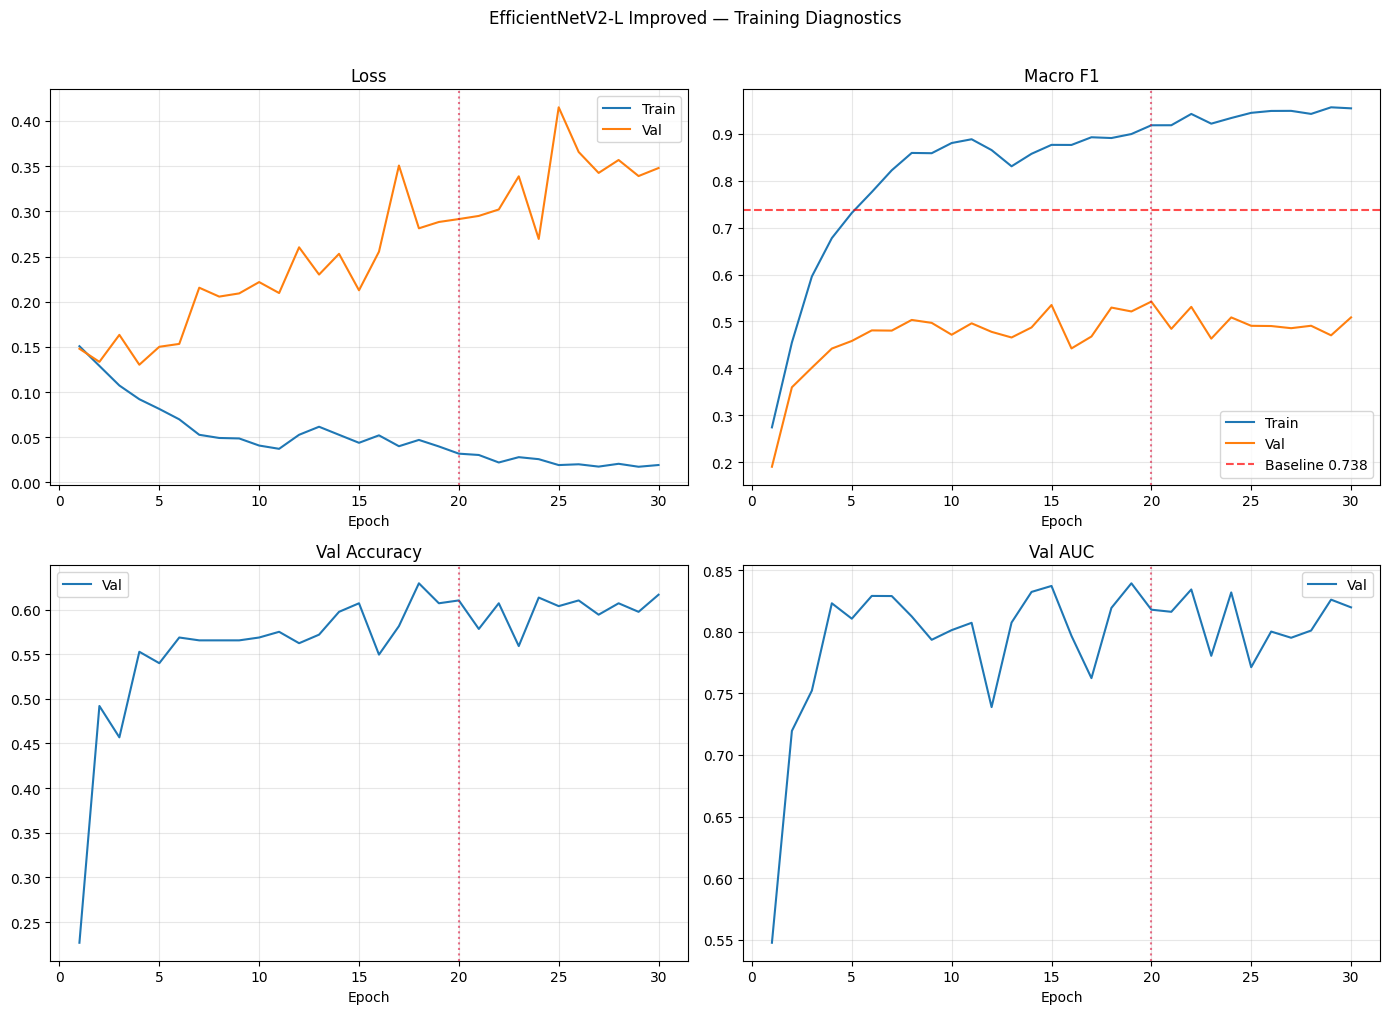

In [115]:
# ============================================================
# CELL 9 — CURVAS DE TREINO
# ============================================================

history_df = pd.read_csv(os.path.join(RESULTS_DIR, 'training_history.csv'))
best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
plot_cols = [
    ('train_loss',      'val_loss',      'Loss'),
    ('train_macro_f1',  'val_macro_f1',  'Macro F1'),
    (None,              'val_accuracy',  'Val Accuracy'),
    (None,              'val_auc',       'Val AUC'),
]
for ax, (tc, vc, title) in zip(axes, plot_cols):
    if tc and tc in history_df.columns:
        ax.plot(history_df['epoch'], history_df[tc], label=f'Train')
    ax.plot(history_df['epoch'], history_df[vc], label='Val')
    if title == 'Macro F1':
        ax.axhline(0.738, color='red', ls='--', alpha=0.7, label='Baseline 0.738')
    ax.axvline(best_epoch, color='crimson', ls=':', alpha=0.6)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('EfficientNetV2-L Improved — Training Diagnostics', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics.png'), dpi=200, bbox_inches='tight')
plt.show()

In [116]:
# ============================================================
# CELL 10 — AVALIAÇÃO NO TESTE (com TTA)
# ============================================================
# Test-Time Augmentation: corre o modelo 4x com variações
# ligeiras da mesma imagem e faz a média das probabilidades.
# Em imagens médicas com alta variabilidade, o TTA costuma
# dar +1 a +3 pontos de F1 sem qualquer re-treino.

model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'best_model.pth'), map_location=device)
)
model.eval()
criterion = FocalLoss(to_onehot_y=True, gamma=2.0)

# ── Avaliação normal (sem TTA) ───────────────────────────────
test_metrics_no_tta, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

# ── Avaliação com TTA ────────────────────────────────────────
def evaluate_tta(model, df_test, tta_transforms, geometry_mode, use_clahe):
    model.eval()
    all_probs_accum = None
    all_targets     = None

    for i, tfm in enumerate(tta_transforms):
        ds     = ERCPDataset(df_test, tfm, geometry_mode, use_clahe)
        loader = DataLoader(ds, BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        probs_run, targets_run = [], []
        with torch.no_grad():
            for images, targets in loader:
                images  = images.to(device)
                outputs = model(images)
                probs   = torch.softmax(outputs, dim=1)
                probs_run.extend(probs.cpu().numpy())
                if all_targets is None:
                    targets_run.extend(targets.numpy())
        if all_probs_accum is None:
            all_probs_accum = np.array(probs_run)
            all_targets     = np.array(targets_run)
        else:
            all_probs_accum += np.array(probs_run)

    all_probs_accum /= len(tta_transforms)
    all_preds = all_probs_accum.argmax(axis=1)
    metrics   = compute_metrics(all_targets, all_preds, all_probs_accum, class_names)
    return metrics, all_targets, all_preds, all_probs_accum


test_metrics_tta, y_true_tta, y_pred_tta, y_prob_tta = evaluate_tta(
    model, test_df, tta_transforms, GEOMETRY_MODE, USE_CLAHE
)

print('=' * 55)
print('RESULTADOS NO TESTE')
print('=' * 55)
print(f"  {'Métrica':<25} {'Sem TTA':>10} {'Com TTA':>10}")
print('-' * 55)
for k in ['macro_f1', 'accuracy', 'balanced_accuracy', 'roc_auc_ovo_macro']:
    v_no  = test_metrics_no_tta.get(k, float('nan'))
    v_tta = test_metrics_tta.get(k, float('nan'))
    print(f"  {k:<25} {v_no:>10.4f} {v_tta:>10.4f}")
print('=' * 55)
print(f"  Baseline artigo:          0.7380")
print(f"  Delta (TTA vs baseline):  {test_metrics_tta['macro_f1'] - 0.738:+.4f}")
print('=' * 55)

# Usar os resultados TTA como resultados finais
y_true = y_true_tta
y_pred = y_pred_tta
y_prob = y_prob_tta
test_metrics = test_metrics_tta

RESULTADOS NO TESTE
  Métrica                      Sem TTA    Com TTA
-------------------------------------------------------
  macro_f1                      0.6485     0.6511
  accuracy                      0.7598     0.7638
  balanced_accuracy             0.6547     0.6550
  roc_auc_ovo_macro             0.8972     0.9198
  Baseline artigo:          0.7380
  Delta (TTA vs baseline):  -0.0869


               precision    recall  f1-score   support

Biliary Leaks       0.44      0.22      0.30        18
    Lithiasis       0.79      0.84      0.82       116
       Normal       0.61      0.80      0.69        35
    Stricture       0.85      0.75      0.80        85

     accuracy                           0.76       254
    macro avg       0.67      0.65      0.65       254
 weighted avg       0.76      0.76      0.76       254



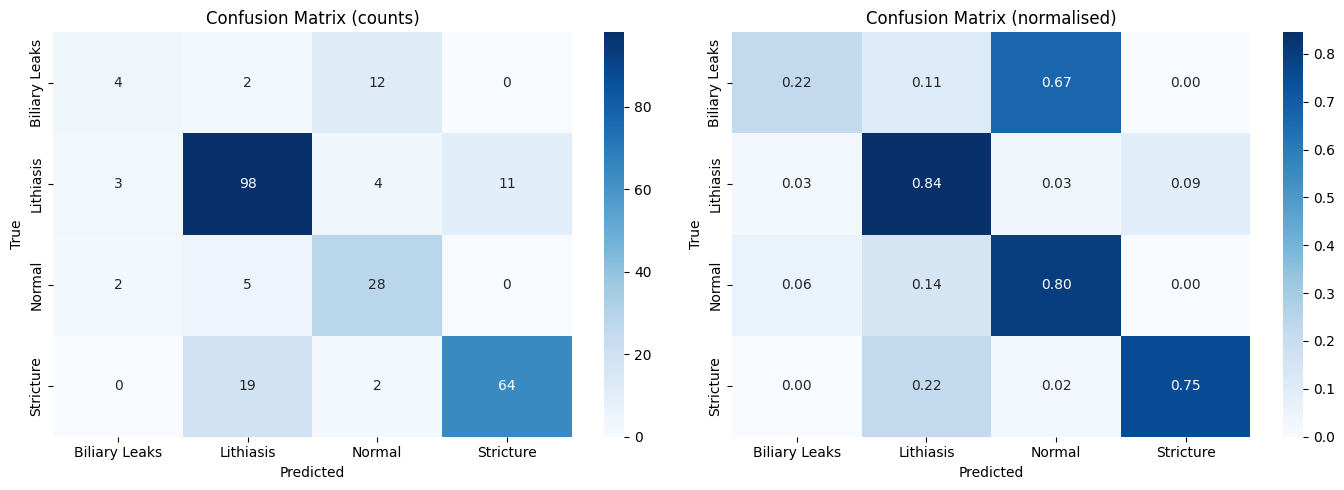

In [117]:
# ============================================================
# CELL 11 — CLASSIFICATION REPORT E CONFUSION MATRIX
# ============================================================

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

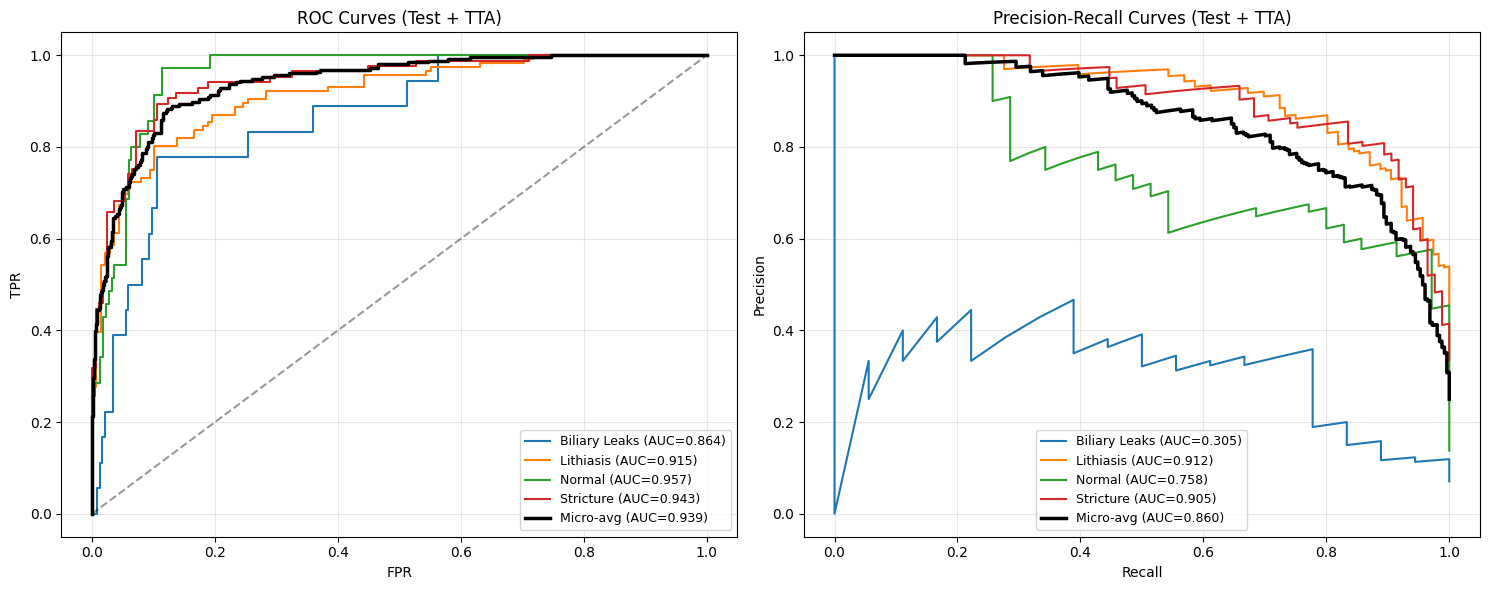

In [118]:
# ============================================================
# CELL 12 — CURVAS ROC E PRECISION-RECALL
# ============================================================

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={auc(fpr,tpr):.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].plot(fpr_micro, tpr_micro,
             label=f'Micro-avg (AUC={roc_auc_micro:.3f})', lw=2.5, color='black')
axes[0].set_title('ROC Curves (Test + TTA)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
pr_auc_micro = auc(rec_micro, prec_micro)
for idx, class_name in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
    axes[1].plot(rec, prec, label=f'{class_name} (AUC={auc(rec,prec):.3f})')
axes[1].plot(rec_micro, prec_micro,
             label=f'Micro-avg (AUC={pr_auc_micro:.3f})', lw=2.5, color='black')
axes[1].set_title('Precision-Recall Curves (Test + TTA)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

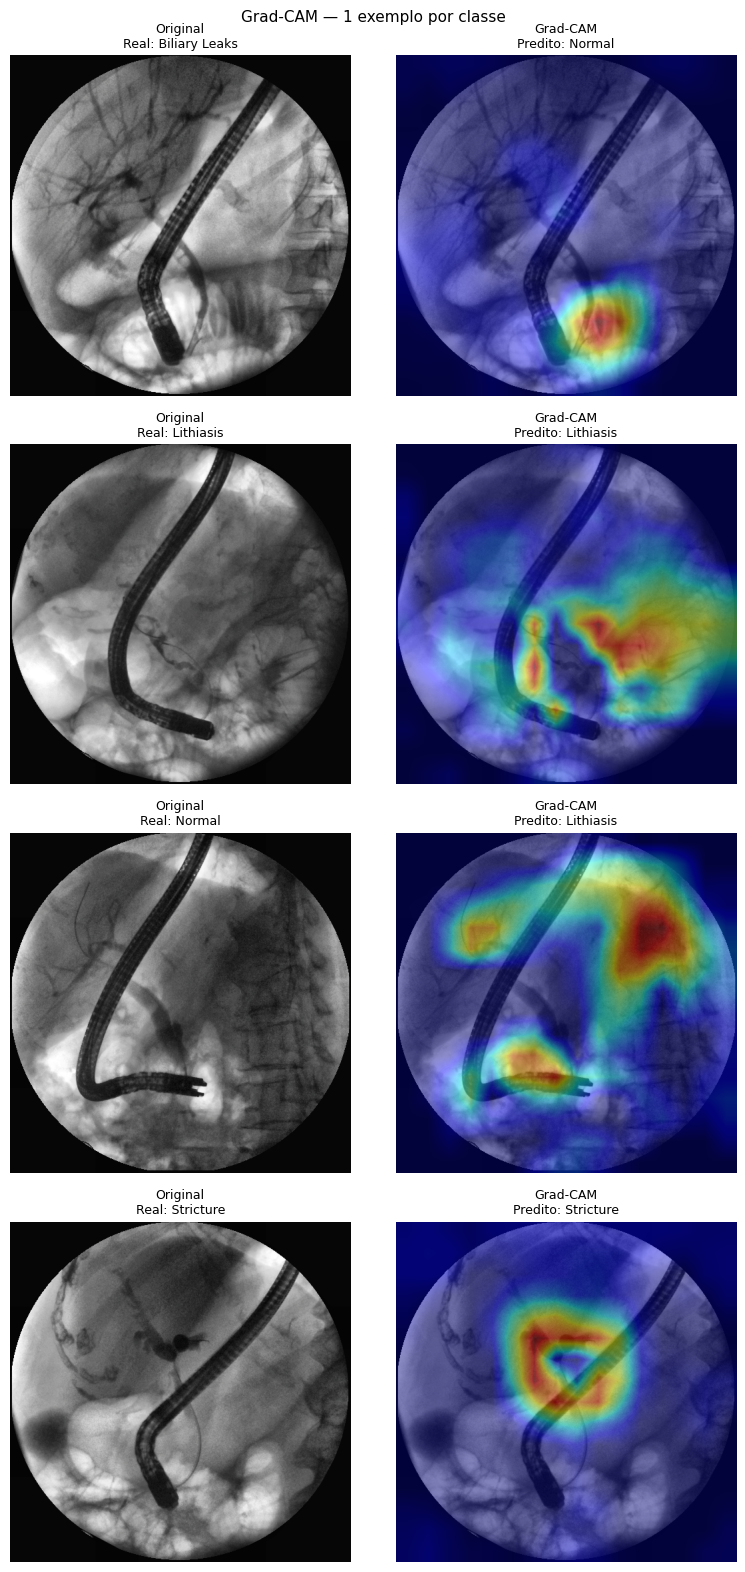

Grad-CAM guardado.


In [119]:
# ============================================================
# CELL 13 — GRAD-CAM (Interpretabilidade)
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, m, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, m, gin, gout):
        self.gradients = gout[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        out = self.model(input_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx


# Última camada convolucional do EfficientNetV2-L
target_layer = model.features[-1][0]
gradcam      = GradCAM(model, target_layer)

denorm = T.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

sample_indices = []
for cls_idx in range(len(class_names)):
    cands = [i for i, (_, lbl) in enumerate(test_ds) if lbl == cls_idx]
    if cands:
        sample_indices.append(random.choice(cands))

import matplotlib.cm as mpl_cm

fig, axes = plt.subplots(len(sample_indices), 2,
                          figsize=(8, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    img_tensor, true_label = test_ds[idx]
    inp = img_tensor.unsqueeze(0).to(device)
    cam, pred_class = gradcam.generate(inp)
    img_vis = denorm(img_tensor).permute(1,2,0).clamp(0,1).numpy()
    cam_res = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    overlay = np.clip(0.55 * img_vis + 0.45 * mpl_cm.jet(cam_res)[:,:,:3], 0, 1)

    axes[row][0].imshow(img_vis, cmap='gray')
    axes[row][0].set_title(f'Original\nReal: {class_names[true_label]}', fontsize=9)
    axes[row][0].axis('off')
    axes[row][1].imshow(overlay)
    axes[row][1].set_title(f'Grad-CAM\nPredito: {class_names[pred_class]}', fontsize=9)
    axes[row][1].axis('off')

plt.suptitle('Grad-CAM — 1 exemplo por classe', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gradcam_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM guardado.')

In [ ]:
# ============================================================
# CELL 14 — GUARDAR RESULTADOS FINAIS
# ============================================================

report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True, zero_division=0
)
with open(os.path.join(RESULTS_DIR, 'classification_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

summary = pd.DataFrame([{
    'model':          'EfficientNetV2-L (improved)',
    'clahe':          USE_CLAHE,
    'clahe_clip':     CLAHE_CLIP,
    'tta':            True,
    'img_size':       IMG_SIZE,
    'baseline_f1':    0.738,
    **{f'test_{k}': v for k, v in test_metrics.items()},
    'delta_vs_baseline': test_metrics['macro_f1'] - 0.738
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary.csv'), index=False)

print('Resultados guardados em', RESULTS_DIR)
